In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from spline import bezier, plotting
import numpy as np
import torch


In [24]:
# control_points: tensor (..., length + 1, order + 1, channels).
control_points = torch.tensor([[[0.0, 0.3], [0.5, 1.], [0.9, 0.2], [1., 1.]], [[1., 1.], [1.1, 1.8], [1.3, 1.5], [2., 1.5]]])
print(control_points.shape)
t = torch.linspace(0., 1., 3)
spline = bezier.BezierSpline(t, control_points)


torch.Size([2, 4, 2])


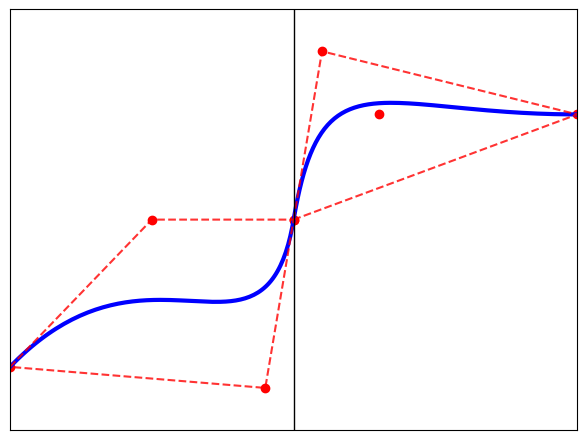

In [ ]:
eval_t = torch.linspace(t[0], t[-2], 50)
fig, ax = plt.subplots(1, 1)
plt.tight_layout()
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(0, 2)
ax.set_xlim(0, 2)
plotting.plot_2d_bezier(t, control_points, ax=ax, points=200, linewidth=3)

first = control_points[0, :, :]
second = control_points[1, :, :]
ax.scatter(first[:, 0], first[:, 1], c="red")
ax.scatter(second[:, 0], second[:, 1], c="red")
order = [0, 1, 3, 2, 0]
second_order = [0, 1, 3, 0]
ax.plot(first[order, 0], first[order, 1], c="red", ls="--", alpha=0.8)
ax.plot(second[second_order, 0], second[second_order, 1], c="red", ls="--", alpha=0.8)

l = np.array([[1., 0.], [1., 2.]])
ax.plot(l[:, 0], l[:, 1], c="black", linewidth=1)


In [27]:
fig.savefig("../../figs/full_bezier.png")